In [1]:
# ============================================================
# İSTANBUL 39 İLÇE SU TÜKETİM TAHMİNİ - LSTM
# Konut ve işyeri ayrı ayrı tahmin edilir, sonra toplanır
# Eğitim: 2020-01 → 2024-12  |  Tahmin: 2025-01 → 2025-10
#
# LSTM mimarisi:
#   Giriş : [y_t-12 ... y_t-1] + exogenous (sıcaklık, abone)
#   Çıkış : y_t+1 ... y_t+10  (direct multi-step)
#   Model  : 2 katmanlı LSTM + Dropout + Dense
#   Strateji: her ilçe için ayrı scaler, tek global model
# ============================================================

# ── AŞAMA 1: KÜTÜPHANELERİ İÇE AKTAR ──────────────────────
# Kurulum: pip install tensorflow  (veya pip install torch)
# Bu notebook TensorFlow/Keras kullanır.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import MinMaxScaler

# Tekrarlanabilirlik için seed
tf.random.set_seed(42)
np.random.seed(42)

print("✅ Kütüphaneler yüklendi")
print(f"   TensorFlow : {tf.__version__}")
print(f"   GPU        : {len(tf.config.list_physical_devices('GPU'))} adet")

✅ Kütüphaneler yüklendi
   TensorFlow : 2.21.0
   GPU        : 0 adet


In [2]:
# ── AŞAMA 2: DOSYA YOLLARI ─────────────────────────────────
ABONE_DOSYA    = r"C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\abone.xlsx"
SU_DOSYA       = r"C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\su_tuketim.xlsx"
SICAKLIK_DOSYA = r"C:\Users\mynet\OneDrive\Masaüstü\Bitirme Projesi\Veriler\sicaklik.xlsx"

In [3]:
# ── AŞAMA 3: YARDIMCI FONKSİYON - TARİH PARSE ─────────────
AYLAR_TR = {
    "Ocak":1, "Şubat":2, "Mart":3, "Nisan":4,
    "Mayıs":5, "Haziran":6, "Temmuz":7, "Ağustos":8,
    "Eylül":9, "Ekim":10, "Kasım":11, "Aralık":12
}

def tarih_parse(tarih_str):
    parcalar = str(tarih_str).strip().split()
    yil = int(parcalar[0])
    ay  = AYLAR_TR[parcalar[-1]]
    return pd.Timestamp(year=yil, month=ay, day=1)

In [4]:
# ── AŞAMA 4: ABONE VERİSİNİ YÜKLE ──────────────────────────
abone_raw = pd.read_excel(ABONE_DOSYA, header=1)

konut = abone_raw.iloc[:, 0:3].copy()
konut.columns = ["ilce", "tarih", "konut_abone"]

isyeri = abone_raw.iloc[:, 8:11].copy()
isyeri.columns = ["ilce", "tarih", "isyeri_abone"]

konut  = konut.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)
isyeri = isyeri.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)

konut["tarih"]  = konut["tarih"].apply(tarih_parse)
isyeri["tarih"] = isyeri["tarih"].apply(tarih_parse)

abone_df = pd.merge(konut, isyeri, on=["ilce", "tarih"], how="outer")
abone_df = abone_df[["ilce", "tarih", "konut_abone", "isyeri_abone"]]
print(f"✅ Abone verisi: {abone_df.shape[0]} satır, {abone_df['ilce'].nunique()} ilçe")

✅ Abone verisi: 2808 satır, 39 ilçe


In [5]:
# ── AŞAMA 5: SU TÜKETİM VERİSİNİ YÜKLE ────────────────────
su_raw = pd.read_excel(SU_DOSYA, header=1)

konut_su = su_raw.iloc[:, 0:3].copy()
konut_su.columns = ["ilce", "tarih", "konut_m3"]

isyeri_su = su_raw.iloc[:, 4:7].copy()
isyeri_su.columns = ["ilce", "tarih", "isyeri_m3"]

konut_su  = konut_su.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)
isyeri_su = isyeri_su.dropna(subset=["ilce", "tarih"]).reset_index(drop=True)

konut_su["tarih"]  = konut_su["tarih"].apply(tarih_parse)
isyeri_su["tarih"] = isyeri_su["tarih"].apply(tarih_parse)

konut_su["konut_m3"]   = pd.to_numeric(konut_su["konut_m3"],   errors="coerce")
isyeri_su["isyeri_m3"] = pd.to_numeric(isyeri_su["isyeri_m3"], errors="coerce")

su_df = pd.merge(konut_su, isyeri_su, on=["ilce", "tarih"], how="outer")
su_df = su_df[["ilce", "tarih", "konut_m3", "isyeri_m3"]]
print(f"✅ Su tüketim verisi: {su_df.shape[0]} satır, {su_df['ilce'].nunique()} ilçe")

✅ Su tüketim verisi: 2808 satır, 39 ilçe


In [6]:
# ── AŞAMA 6: SICAKLIK VERİSİNİ YÜKLE ───────────────────────
# header=1 → 2. satırı başlık olarak oku (ilk satır boş)
sicaklik_raw = pd.read_excel(SICAKLIK_DOSYA, header=1)

sicaklik_df = sicaklik_raw.rename(columns={
    "İLÇE": "ilce",
    "TARİH": "tarih",
    "ORTALAMA SICAKLIK": "sicaklik_c"
})

# "2020   Ocak" → datetime
tarih_split = sicaklik_df["tarih"].astype(str).str.strip().str.split(r"\s+", expand=True)
sicaklik_df["tarih"] = pd.to_datetime(
    tarih_split[0] + "-" + tarih_split[1].map(AYLAR_TR).astype(str),
    format="%Y-%m"
)

sicaklik_df["sicaklik_c"] = (
    sicaklik_df["sicaklik_c"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

sicaklik_df["ilce"] = sicaklik_df["ilce"].str.upper().str.strip()

print(f"✅ Sıcaklık verisi: {sicaklik_df.shape[0]} satır, {sicaklik_df['ilce'].nunique()} ilçe")

✅ Sıcaklık verisi: 2808 satır, 39 ilçe


In [7]:
# ── AŞAMA 7: İLÇE İSİMLERİNİ EŞLEŞTİR ─────────────────────
#eşleşmeyen ilçeler
ilce_su       = set(su_df["ilce"].str.upper().str.strip().unique())
ilce_abone    = set(abone_df["ilce"].str.upper().str.strip().unique())
ilce_sicaklik = set(sicaklik_df["ilce"].unique())

print(f"Su verisi      : {len(ilce_su)} ilçe")
print(f"Abone verisi   : {len(ilce_abone)} ilçe")
print(f"Sıcaklık verisi: {len(ilce_sicaklik)} ilçe")

print("\n── Su ∩ Abone ──────────────────────────────")
print("🔴 Abonede olup suda OLMAYAN  :", ilce_abone - ilce_su)
print("🔵 Suda olup abonede OLMAYAN  :", ilce_su - ilce_abone)

print("\n── Su ∩ Sıcaklık ───────────────────────────")
print("🔴 Sıcaklıkta olup suda OLMAYAN  :", ilce_sicaklik - ilce_su)
print("🔵 Suda olup sıcaklıkta OLMAYAN  :", ilce_su - ilce_sicaklik)

print("\n── Üç sette birden olan ilçe sayısı ────────")
print("✅", len(ilce_su & ilce_abone & ilce_sicaklik), "ilçe tam eşleşiyor")

print("\n── Üç setten herhangi birinde eksik olanlar ─")
tum_ilceler = ilce_su | ilce_abone | ilce_sicaklik
eksik = {i: [] for i in tum_ilceler}
for i in tum_ilceler:
    if i not in ilce_su:       eksik[i].append("su yok")
    if i not in ilce_abone:    eksik[i].append("abone yok")
    if i not in ilce_sicaklik: eksik[i].append("sıcaklık yok")
eksik = {k: v for k, v in eksik.items() if v}
for ilce, sorun in sorted(eksik.items()):
    print(f"  {ilce:25s} → {', '.join(sorun)}")

Su verisi      : 39 ilçe
Abone verisi   : 39 ilçe
Sıcaklık verisi: 39 ilçe

── Su ∩ Abone ──────────────────────────────
🔴 Abonede olup suda OLMAYAN  : set()
🔵 Suda olup abonede OLMAYAN  : set()

── Su ∩ Sıcaklık ───────────────────────────
🔴 Sıcaklıkta olup suda OLMAYAN  : set()
🔵 Suda olup sıcaklıkta OLMAYAN  : set()

── Üç sette birden olan ilçe sayısı ────────
✅ 39 ilçe tam eşleşiyor

── Üç setten herhangi birinde eksik olanlar ─


In [8]:
# Aşama 7 sonrası doğrulama
ilce_su       = set(su_df["ilce"].str.upper().str.strip().unique())
ilce_sicaklik = set(sicaklik_df["ilce"].unique())
eksik = ilce_sicaklik - ilce_su
if eksik:
    print(f"⚠️  Hâlâ eşleşmeyen {len(eksik)} ilçe var: {eksik}")
else:
    print("✅ Tüm 39 ilçe eşleşiyor, devam edilebilir")

✅ Tüm 39 ilçe eşleşiyor, devam edilebilir


In [9]:
# ── AŞAMA 8: ÜÇ VERİYİ BİRLEŞTİR ──────────────────────────
df = (
    su_df
    .merge(abone_df,    on=["ilce", "tarih"], how="inner")
    .merge(sicaklik_df, on=["ilce", "tarih"], how="inner")
)
df = df[["ilce","tarih","konut_m3","isyeri_m3",
         "konut_abone","isyeri_abone","sicaklik_c"]]
df["yil"] = df["tarih"].dt.year
df["ay"]  = df["tarih"].dt.month
df["su_tuketimi_m3"] = df["konut_m3"] + df["isyeri_m3"]
print(f"✅ Birleşik veri: {df.shape[0]} satır, {df['ilce'].nunique()} ilçe")
print(f"📅 Tarih aralığı: {df['tarih'].min().strftime('%Y-%m')} → {df['tarih'].max().strftime('%Y-%m')}")

✅ Birleşik veri: 2808 satır, 39 ilçe
📅 Tarih aralığı: 2020-01 → 2025-12


In [10]:
# ── AŞAMA 9: KEŞİFÇİ ANALİZ ────────────────────────────────
ilce_ort = df.groupby("ilce")["su_tuketimi_m3"].mean().sort_values(ascending=False)
yillik   = df.groupby("yil")["su_tuketimi_m3"].sum()
print("📊 GENEL İSTATİSTİKLER")
print(df[["su_tuketimi_m3","konut_m3","isyeri_m3","sicaklik_c"]].describe().round(2))
print("\n📅 YILLIK TOPLAM:")
print(yillik.apply(lambda x: f"{x:,.0f}").to_string())

📊 GENEL İSTATİSTİKLER
       su_tuketimi_m3    konut_m3   isyeri_m3  sicaklik_c
count         2808.00     2808.00     2808.00     2808.00
mean       1916492.43  1475069.18   441423.25       16.14
std         915371.40   724748.78   297589.20        6.72
min          22357.00    16817.00     2948.00        3.24
25%        1324871.75   958896.25   246765.50       10.13
50%        1842157.50  1428302.00   392879.50       15.77
75%        2362685.75  1872815.00   583546.00       22.51
max        6613796.00  4609887.00  5189876.00       28.28

📅 YILLIK TOPLAM:
yil
2020    857,292,555
2021    842,827,358
2022    901,007,924
2023    911,272,787
2024    944,775,278
2025    924,334,837


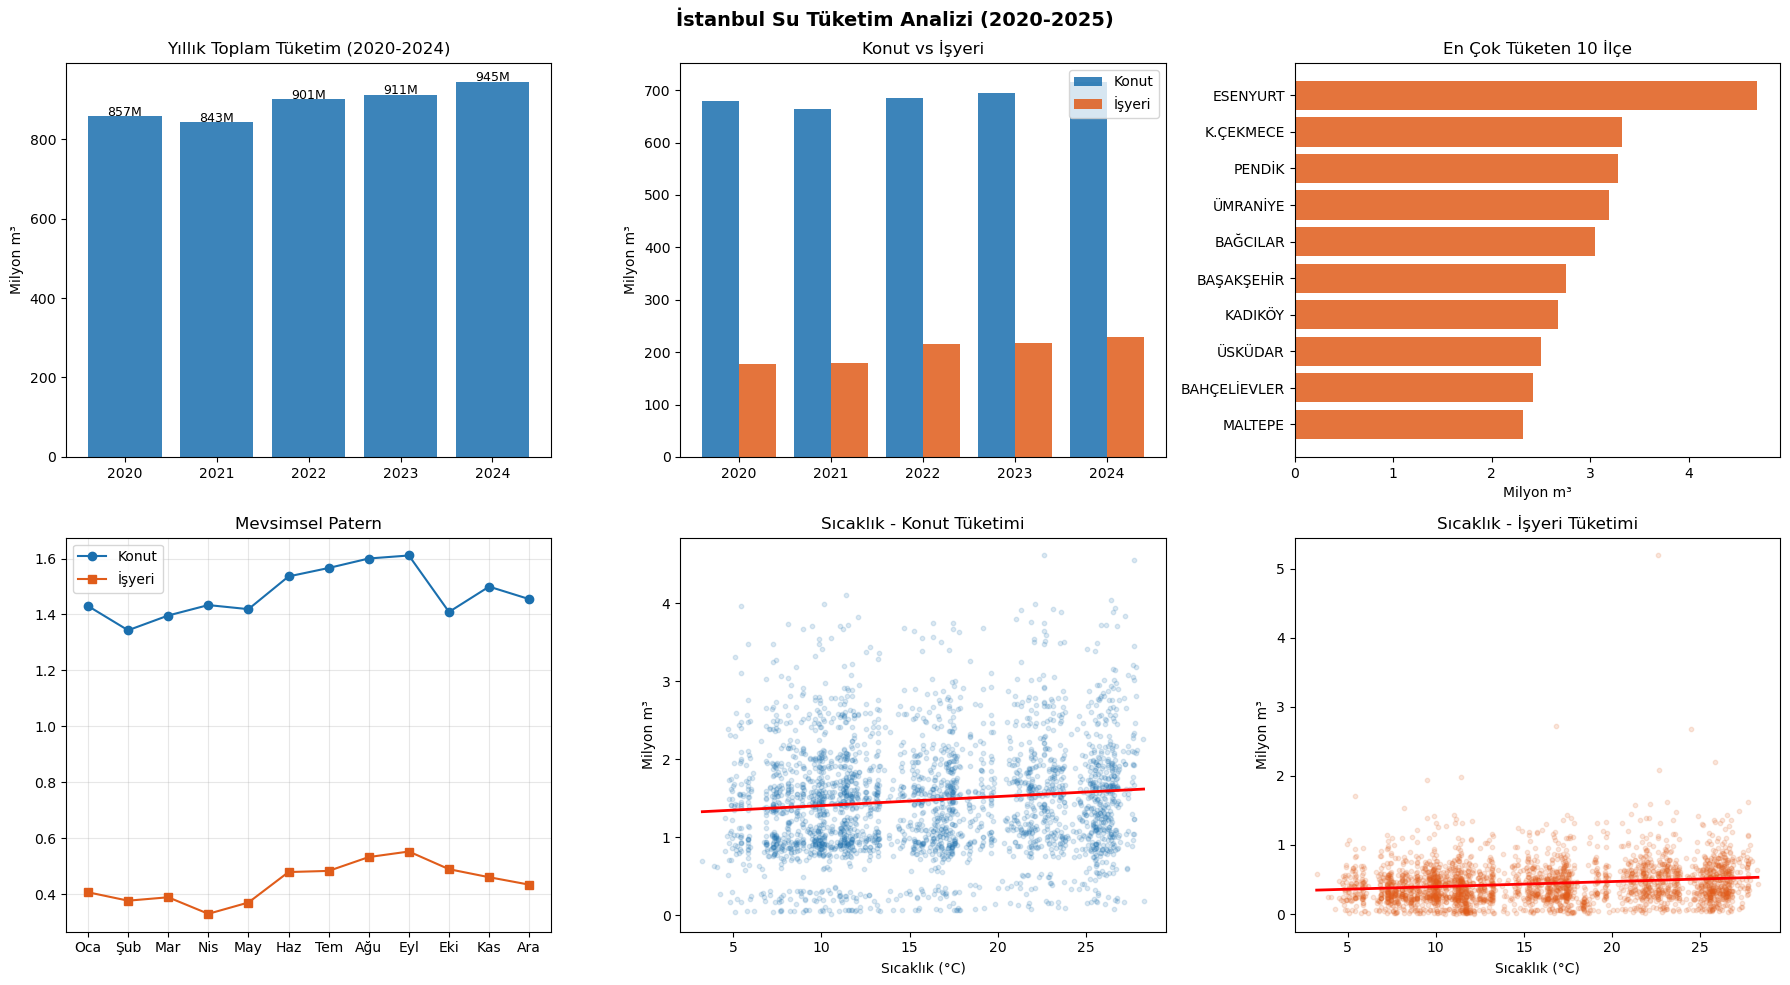

✅ Grafik kaydedildi: analiz.png


In [11]:
# ── AŞAMA 10: KEŞİFÇİ GRAFİKLER ───────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    "İstanbul Su Tüketim Analizi (2020-2025)",
    fontsize=14,
    fontweight="bold"
)

# ─────────────────────────────────────────────
# Yıllık toplam tüketim
# ─────────────────────────────────────────────

ax1 = axes[0, 0]

yillik_tam = (
    df[df["yil"] < 2025]
    .groupby("yil")["su_tuketimi_m3"]
    .sum() / 1e6
)

ax1.bar(
    yillik_tam.index,
    yillik_tam.values,
    color="#1a6fae",
    alpha=0.85
)

ax1.set_title("Yıllık Toplam Tüketim (2020-2024)")
ax1.set_ylabel("Milyon m³")
ax1.set_xticks(yillik_tam.index)

for i, v in enumerate(yillik_tam.values):
    ax1.text(
        yillik_tam.index[i],
        v + 1,
        f"{v:.0f}M",
        ha="center",
        fontsize=9
    )

# ─────────────────────────────────────────────
# Konut vs İşyeri
# ─────────────────────────────────────────────

ax2 = axes[0, 1]

yillik_konut = (
    df[df["yil"] < 2025]
    .groupby("yil")["konut_m3"]
    .sum() / 1e6
)

yillik_isyeri = (
    df[df["yil"] < 2025]
    .groupby("yil")["isyeri_m3"]
    .sum() / 1e6
)

x = np.arange(len(yillik_konut))

ax2.bar(
    x - 0.2,
    yillik_konut.values,
    width=0.4,
    label="Konut",
    color="#1a6fae",
    alpha=0.85
)

ax2.bar(
    x + 0.2,
    yillik_isyeri.values,
    width=0.4,
    label="İşyeri",
    color="#e05c1a",
    alpha=0.85
)

ax2.set_title("Konut vs İşyeri")
ax2.set_ylabel("Milyon m³")
ax2.set_xticks(x)
ax2.set_xticklabels(yillik_konut.index)
ax2.legend()

# ─────────────────────────────────────────────
# İlçeler
# ─────────────────────────────────────────────

ax3 = axes[0, 2]

top10 = ilce_ort.head(10) / 1e6

ax3.barh(
    top10.index[::-1],
    top10.values[::-1],
    color="#e05c1a",
    alpha=0.85
)

ax3.set_title("En Çok Tüketen 10 İlçe")
ax3.set_xlabel("Milyon m³")

# ─────────────────────────────────────────────
# Mevsimsellik
# ─────────────────────────────────────────────

ax4 = axes[1, 0]

aylik_konut = (
    df.groupby("ay")["konut_m3"]
    .mean() / 1e6
)

aylik_isyeri = (
    df.groupby("ay")["isyeri_m3"]
    .mean() / 1e6
)

ay_isimleri = [
    "Oca","Şub","Mar","Nis",
    "May","Haz","Tem","Ağu",
    "Eyl","Eki","Kas","Ara"
]

ax4.plot(
    aylik_konut.index,
    aylik_konut.values,
    color="#1a6fae",
    marker="o",
    label="Konut"
)

ax4.plot(
    aylik_isyeri.index,
    aylik_isyeri.values,
    color="#e05c1a",
    marker="s",
    label="İşyeri"
)

ax4.set_title("Mevsimsel Patern")
ax4.set_xticks(range(1, 13))
ax4.set_xticklabels(ay_isimleri)
ax4.legend()
ax4.grid(True, alpha=0.3)

# ─────────────────────────────────────────────
# SICAKLIK - KONUT
# ─────────────────────────────────────────────

ax5 = axes[1, 1]

x1 = pd.to_numeric(
    df["sicaklik_c"],
    errors="coerce"
)

y1 = pd.to_numeric(
    df["konut_m3"],
    errors="coerce"
) / 1e6

mask1 = (
    np.isfinite(x1) &
    np.isfinite(y1)
)

x1 = x1[mask1]
y1 = y1[mask1]

ax5.scatter(
    x1,
    y1,
    alpha=0.15,
    color="#1a6fae",
    s=10
)

ax5.set_title("Sıcaklık - Konut Tüketimi")
ax5.set_xlabel("Sıcaklık (°C)")
ax5.set_ylabel("Milyon m³")

if len(x1) > 1:

    z = np.polyfit(x1, y1, 1)

    xp = np.linspace(
        x1.min(),
        x1.max(),
        100
    )

    ax5.plot(
        xp,
        np.poly1d(z)(xp),
        color="red",
        linewidth=2
    )

# ─────────────────────────────────────────────
# SICAKLIK - İŞYERİ
# ─────────────────────────────────────────────

ax6 = axes[1, 2]

x2 = pd.to_numeric(
    df["sicaklik_c"],
    errors="coerce"
)

y2 = pd.to_numeric(
    df["isyeri_m3"],
    errors="coerce"
) / 1e6

mask2 = (
    np.isfinite(x2) &
    np.isfinite(y2)
)

x2 = x2[mask2]
y2 = y2[mask2]

ax6.scatter(
    x2,
    y2,
    alpha=0.15,
    color="#e05c1a",
    s=10
)

ax6.set_title("Sıcaklık - İşyeri Tüketimi")
ax6.set_xlabel("Sıcaklık (°C)")
ax6.set_ylabel("Milyon m³")

if len(x2) > 1:

    z2 = np.polyfit(x2, y2, 1)

    xp2 = np.linspace(
        x2.min(),
        x2.max(),
        100
    )

    ax6.plot(
        xp2,
        np.poly1d(z2)(xp2),
        color="red",
        linewidth=2
    )

# ─────────────────────────────────────────────

plt.tight_layout()

plt.savefig(
    "analiz.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("✅ Grafik kaydedildi: analiz.png")

In [12]:
# ── AŞAMA 11: LSTM İÇİN VERİ HAZIRLAMA ────────────────────
#
# LSTM'in LightGBM'den farkı:
#   Giriş: 3D tensor → (örnekler, zaman_adımı, özellik_sayısı)
#   Zaman penceresi (lookback): kaç geçmiş adıma bakılacak
#   Çıkış: doğrudan 10 adım → Direct Multi-Step strateji
#
# Özellikler her zaman adımı için:
#   [y, sicaklik_c, konut_abone, isyeri_abone, ay_sin, ay_cos]
#
# Her ilçe için ayrı MinMaxScaler kullanılır (y kolonuna)
# Exogenous değişkenler de normalize edilir

LOOKBACK  = 24   # kaç geçmiş ay kullanılacak (pencere boyutu)
H         = 12   # tahmin ufku
EXOG_COLS = ["sicaklik_c", "konut_abone", "isyeri_abone"]

# Özellik sütunları (y + exog + takvim)
FEATURE_COLS = ["y"] + EXOG_COLS + ["ay_sin", "ay_cos"]
N_FEATURES   = len(FEATURE_COLS)

print(f"✅ LSTM yapılandırması:")
print(f"   Lookback (pencere): {LOOKBACK} ay")
print(f"   Tahmin ufku       : {H} ay")
print(f"   Özellik sayısı    : {N_FEATURES} → {FEATURE_COLS}")

✅ LSTM yapılandırması:
   Lookback (pencere): 24 ay
   Tahmin ufku       : 12 ay
   Özellik sayısı    : 6 → ['y', 'sicaklik_c', 'konut_abone', 'isyeri_abone', 'ay_sin', 'ay_cos']


In [13]:
# ── AŞAMA 12: VERİ ÖN İŞLEME FONKSİYONLARI ───────────────

def veri_hazirla(df, hedef_col, context_bitis="2024-12-01"):
    """
    Ham df'den LSTM için hazır DataFrame üretir.
    Eksik tarihleri doldurur, takvim özelliklerini ekler.
    """
    df_fmt = df[["ilce", "tarih", hedef_col] + EXOG_COLS].copy()
    df_fmt = df_fmt.rename(columns={"ilce":"unique_id", "tarih":"ds", hedef_col:"y"})

    # Eksik tarihleri doldur
    tam_tarih = pd.date_range(start="2020-01-01", end=df_fmt["ds"].max(), freq="MS")
    parcalar  = []
    for ilce in df_fmt["unique_id"].unique():
        p = df_fmt[df_fmt["unique_id"] == ilce].set_index("ds").reindex(tam_tarih)
        p["unique_id"] = ilce
        p.index.name   = "ds"
        p = p.reset_index()
        for col in ["y"] + EXOG_COLS:
            p[col] = p[col].interpolate(method="linear").ffill().bfill()
        parcalar.append(p)
    df_fmt = pd.concat(parcalar).reset_index(drop=True)

    # Takvim özellikleri (sinüs/kosinüs encoding)
    df_fmt["ay_sin"] = np.sin(2 * np.pi * df_fmt["ds"].dt.month / 12)
    df_fmt["ay_cos"] = np.cos(2 * np.pi * df_fmt["ds"].dt.month / 12)

    df_ctx = df_fmt[df_fmt["ds"] <= context_bitis].copy()
    df_val = df_fmt[df_fmt["ds"] >  context_bitis].copy()
    return df_fmt, df_ctx, df_val


def pencere_olustur(df_ctx, df_val, scalers, lookback=LOOKBACK, h=H):
    """
    Her ilçe için:
      1. MinMaxScaler fit et (ctx üzerinde)
      2. Sliding window örnekleri oluştur → X: (lookback, features), y: (h,)
      3. Validasyon için son lookback adımını hazırla
    """
    X_list, y_list = [], []
    X_pred_list    = []   # her ilçenin tahmin girişi
    ilce_sirasi    = []

    for ilce in df_ctx["unique_id"].unique():
        ctx = df_ctx[df_ctx["unique_id"] == ilce].sort_values("ds")
        val = df_val[df_val["unique_id"] == ilce].sort_values("ds")

        # Scaler: sadece y kolonu için (exog ayrı normalize edilir)
        sc_y    = MinMaxScaler()
        sc_exog = MinMaxScaler()

        y_scaled    = sc_y.fit_transform(ctx[["y"]]).flatten()
        exog_scaled = sc_exog.fit_transform(ctx[EXOG_COLS + ["ay_sin","ay_cos"]])

        scalers[ilce] = {"y": sc_y, "exog": sc_exog}

        # Tam özellik matrisi (ctx)
        feat_ctx = np.column_stack([y_scaled, exog_scaled])  # (T, N_FEATURES)

        # Sliding window örnekleri
        for i in range(lookback, len(feat_ctx) - h + 1):
            X_list.append(feat_ctx[i - lookback : i])
            y_list.append(y_scaled[i : i + h])

        # Tahmin için giriş: son lookback adım (ctx) + val exog
        val_exog_scaled = sc_exog.transform(val[EXOG_COLS + ["ay_sin","ay_cos"]].head(h))
        # Son ctx y değerleri + val exog birleştirilmiş buffer
        son_ctx = feat_ctx[-lookback:].copy()   # shape: (lookback, N_FEATURES)
        X_pred_list.append(son_ctx)
        ilce_sirasi.append((ilce, val["ds"].head(h).values, val_exog_scaled, sc_y))

    X = np.array(X_list, dtype=np.float32)   # (örnekler, lookback, features)
    y = np.array(y_list, dtype=np.float32)   # (örnekler, h)
    return X, y, X_pred_list, ilce_sirasi


# Veri hazırla
df_full_konut,  df_ctx_konut,  df_val_konut  = veri_hazirla(df, "konut_m3")
df_full_isyeri, df_ctx_isyeri, df_val_isyeri = veri_hazirla(df, "isyeri_m3")

# Pencere oluştur
scalers_konut,  scalers_isyeri = {}, {}
X_k, y_k, X_pred_k, ilce_k = pencere_olustur(df_ctx_konut,  df_val_konut,  scalers_konut)
X_i, y_i, X_pred_i, ilce_i = pencere_olustur(df_ctx_isyeri, df_val_isyeri, scalers_isyeri)

print(f"✅ Konut   X: {X_k.shape}, y: {y_k.shape}")
print(f"✅ İşyeri  X: {X_i.shape}, y: {y_i.shape}")
print(f"   Giriş şekli : (örnekler={X_k.shape[0]}, lookback={X_k.shape[1]}, özellik={X_k.shape[2]})")

✅ Konut   X: (975, 24, 6), y: (975, 12)
✅ İşyeri  X: (975, 24, 6), y: (975, 12)
   Giriş şekli : (örnekler=975, lookback=24, özellik=6)


In [14]:
# ── AŞAMA 13: LSTM MODELİ ──────────────────────────────────
#
# Mimari:
#   LSTM(128) → Dropout(0.2)
#   LSTM(64)  → Dropout(0.2)
#   Dense(64, relu)
#   Dense(H)  → 10 adım doğrudan tahmin (direct multi-step)
#
# Tek model hem konut hem işyeri için eğitilir (ayrı ayrı)

def lstm_modeli_olustur(lookback=LOOKBACK, n_features=N_FEATURES, h=H):
    model = keras.Sequential([
        layers.Input(shape=(lookback, n_features)),

        # 1. LSTM katmanı — return_sequences=True → sonraki LSTM'e tam dizi ver
        layers.LSTM(128, return_sequences=True),
        layers.Dropout(0.2),

        # 2. LSTM katmanı — return_sequences=False → sadece son adım
        layers.LSTM(64, return_sequences=False),
        layers.Dropout(0.2),

        # Tam bağlı katmanlar
        layers.Dense(64, activation="relu"),
        layers.Dense(h),   # Çıkış: H adım tahmini
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="huber",        # Huber loss → aykırı değerlere karşı sağlam
        metrics=["mae"]
    )
    return model

# Model özetini göster
ornek_model = lstm_modeli_olustur()
ornek_model.summary()
print(f"\n✅ LSTM modeli oluşturuldu")
print(f"   Toplam parametre: {ornek_model.count_params():,}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        69,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,468 (482.30 KB)

 Trainable params: 123,468 (482.30 KB)

 Non-trainable params: 0 (0.00 B)


✅ LSTM modeli oluşturuldu
   Toplam parametre: 123,468


In [15]:
# ── AŞAMA 14: MODEL EĞİTİMİ — KONUT ───────────────────────
#
# Callbacks:
#   EarlyStopping  → val_loss iyileşmezse dur (patience=20)
#   ReduceLROnPlateau → öğrenme hızını azalt
#   ModelCheckpoint → en iyi modeli kaydet

# Train/validation ayrımı (%85 train, %15 val — zaman sırası korunur)
kesim_k = int(len(X_k) * 0.85)
X_k_train, X_k_val = X_k[:kesim_k], X_k[kesim_k:]
y_k_train, y_k_val = y_k[:kesim_k], y_k[kesim_k:]

cb_konut = [
    callbacks.EarlyStopping(monitor="val_loss", patience=20,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=10, min_lr=1e-6, verbose=0),
    callbacks.ModelCheckpoint("best_lstm_konut.keras",
                              monitor="val_loss", save_best_only=True, verbose=0),
]

model_konut = lstm_modeli_olustur()
history_k   = model_konut.fit(
    X_k_train, y_k_train,
    validation_data = (X_k_val, y_k_val),
    epochs          = 200,
    batch_size      = 32,
    callbacks       = cb_konut,
    verbose         = 0,
)

print(f"✅ Konut modeli eğitildi — {len(history_k.history['loss'])} epoch")
print(f"   En iyi val_loss: {min(history_k.history['val_loss']):.6f}")
print(f"   En iyi val_mae : {min(history_k.history['val_mae']):.2f}")

Epoch 116: early stopping
Restoring model weights from the end of the best epoch: 96.
✅ Konut modeli eğitildi — 116 epoch
   En iyi val_loss: 0.004978
   En iyi val_mae : 0.07


In [16]:
# ── AŞAMA 15: MODEL EĞİTİMİ — İŞYERİ ──────────────────────
kesim_i = int(len(X_i) * 0.85)
X_i_train, X_i_val = X_i[:kesim_i], X_i[kesim_i:]
y_i_train, y_i_val = y_i[:kesim_i], y_i[kesim_i:]

cb_isyeri = [
    callbacks.EarlyStopping(monitor="val_loss", patience=20,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=10, min_lr=1e-6, verbose=0),
    callbacks.ModelCheckpoint("best_lstm_isyeri.keras",
                              monitor="val_loss", save_best_only=True, verbose=0),
]

model_isyeri = lstm_modeli_olustur()
history_i    = model_isyeri.fit(
    X_i_train, y_i_train,
    validation_data = (X_i_val, y_i_val),
    epochs          = 200,
    batch_size      = 32,
    callbacks       = cb_isyeri,
    verbose         = 0,
)

print(f"✅ İşyeri modeli eğitildi — {len(history_i.history['loss'])} epoch")
print(f"   En iyi val_loss: {min(history_i.history['val_loss']):.6f}")
print(f"   En iyi val_mae : {min(history_i.history['val_mae']):.2f}")

Epoch 50: early stopping
Restoring model weights from the end of the best epoch: 30.
✅ İşyeri modeli eğitildi — 50 epoch
   En iyi val_loss: 0.006703
   En iyi val_mae : 0.08


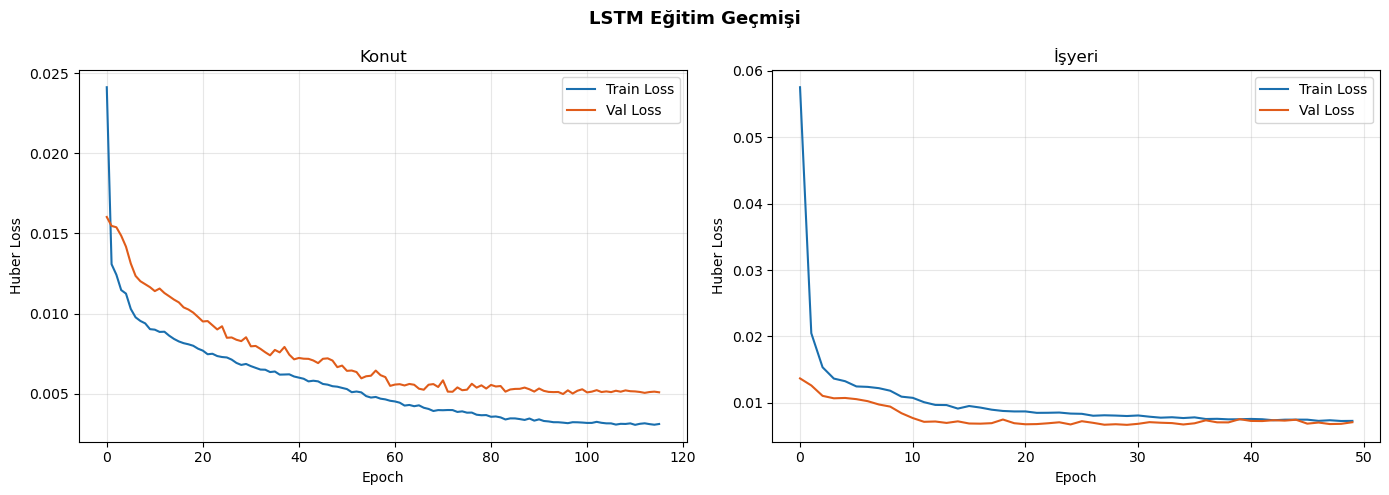

✅ Eğitim grafiği kaydedildi


In [17]:
# ── AŞAMA 16: EĞİTİM GRAFİĞİ ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LSTM Eğitim Geçmişi", fontsize=13, fontweight="bold")

for ax, hist, baslik in zip(axes,
                             [history_k, history_i],
                             ["Konut", "İşyeri"]):
    ax.plot(hist.history["loss"],     label="Train Loss", color="#1a6fae")
    ax.plot(hist.history["val_loss"], label="Val Loss",   color="#e05c1a")
    ax.set_title(baslik)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Huber Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("egitim_gecmisi_lstm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Eğitim grafiği kaydedildi")

In [18]:
# ── AŞAMA 17: LSTM TAHMİN FONKSİYONU ──────────────────────
#
# Direct multi-step strateji:
#   Model zaten H=10 adım çıkış üretiyor.
#   Her ilçi için son LOOKBACK adımı girişe ver, 10 adım al.
#   Scaler ile gerçek değere çevir.

def lstm_tahmin_yap(model, X_pred_list, ilce_sirasi, etiket=""):
    sonuclar = []
    print(f"⏳ {etiket} LSTM tahmini başlıyor...")

    for idx, (ilce, tarihler, val_exog_scaled, sc_y) in enumerate(ilce_sirasi):
        # Giriş tensoru: (1, lookback, n_features)
        X_in = X_pred_list[idx][np.newaxis, :, :].astype(np.float32)

        # Tahmin (normalized uzayda)
        y_pred_scaled = model.predict(X_in, verbose=0)[0]   # shape: (H,)

        # Gerçek ölçeğe çevir
        y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        y_pred = np.maximum(y_pred, 0)   # negatif olamaz

        ilce_df = pd.DataFrame({
            "unique_id" : ilce,
            "ds"        : tarihler,
            "tahmin"    : y_pred,
        })
        sonuclar.append(ilce_df)

    print(f"✅ {etiket} tahmini tamamlandı — {len(sonuclar)} ilçe")
    return pd.concat(sonuclar).reset_index(drop=True)

print("✅ LSTM tahmin fonksiyonu tanımlandı")

✅ LSTM tahmin fonksiyonu tanımlandı


In [19]:
# ── AŞAMA 18: TAHMİNLERİ ÜRETİP BİRLEŞTİR ────────────────
tahmin_konut_raw  = lstm_tahmin_yap(model_konut,  X_pred_k, ilce_k, "Konut")
tahmin_isyeri_raw = lstm_tahmin_yap(model_isyeri, X_pred_i, ilce_i, "İşyeri")

tahmin_konut  = tahmin_konut_raw.rename(columns={"tahmin": "konut_tahmin"})
tahmin_isyeri = tahmin_isyeri_raw.rename(columns={"tahmin": "isyeri_tahmin"})

tahminler = tahmin_konut.merge(tahmin_isyeri, on=["unique_id", "ds"], how="inner")
tahminler["toplam_tahmin"] = tahminler["konut_tahmin"] + tahminler["isyeri_tahmin"]

print(f"✅ Tahminler birleştirildi: {tahminler.shape[0]} satır")
print(tahminler.head())

⏳ Konut LSTM tahmini başlıyor...
✅ Konut tahmini tamamlandı — 39 ilçe
⏳ İşyeri LSTM tahmini başlıyor...
✅ İşyeri tahmini tamamlandı — 39 ilçe
✅ Tahminler birleştirildi: 468 satır
  unique_id         ds  konut_tahmin  isyeri_tahmin  toplam_tahmin
0    ADALAR 2025-01-01  62212.542969   85159.851562  147372.390625
1    ADALAR 2025-02-01  43954.199219   82954.023438  126908.218750
2    ADALAR 2025-03-01  56322.953125   78725.226562  135048.187500
3    ADALAR 2025-04-01  74856.539062   55138.640625  129995.179688
4    ADALAR 2025-05-01  79769.750000   96889.062500  176658.812500


In [20]:
# ── AŞAMA 19: PERFORMANS DEĞERLENDİRMESİ ───────────────────
gercek_k = df_val_konut[["unique_id",  "ds", "y"]].rename(columns={"y": "konut_gercek"})
gercek_i = df_val_isyeri[["unique_id", "ds", "y"]].rename(columns={"y": "isyeri_gercek"})
gercek   = gercek_k.merge(gercek_i, on=["unique_id", "ds"])
gercek["toplam_gercek"] = gercek["konut_gercek"] + gercek["isyeri_gercek"]

karsilastirma = tahminler.merge(gercek, on=["unique_id", "ds"], how="inner")

def mape_hesapla(gercek, tahmin):
    return (gercek - tahmin).abs() / gercek.abs() * 100

karsilastirma["mape_konut"]  = mape_hesapla(karsilastirma["konut_gercek"],  karsilastirma["konut_tahmin"])
karsilastirma["mape_isyeri"] = mape_hesapla(karsilastirma["isyeri_gercek"], karsilastirma["isyeri_tahmin"])
karsilastirma["mape_toplam"] = mape_hesapla(karsilastirma["toplam_gercek"], karsilastirma["toplam_tahmin"])
karsilastirma["abs_konut"]   = (karsilastirma["konut_gercek"]  - karsilastirma["konut_tahmin"]).abs()
karsilastirma["abs_isyeri"]  = (karsilastirma["isyeri_gercek"] - karsilastirma["isyeri_tahmin"]).abs()
karsilastirma["abs_toplam"]  = (karsilastirma["toplam_gercek"] - karsilastirma["toplam_tahmin"]).abs()

metrikler = (
    karsilastirma
    .groupby("unique_id")
    .agg(
        MAPE_Konut  = ("mape_konut",  "mean"),
        MAPE_Isyeri = ("mape_isyeri", "mean"),
        MAPE_Toplam = ("mape_toplam", "mean"),
        MAE_Konut   = ("abs_konut",   "mean"),
        MAE_Isyeri  = ("abs_isyeri",  "mean"),
        MAE_Toplam  = ("abs_toplam",  "mean"),
        RMSE_Konut  = ("abs_konut",   lambda x: np.sqrt((x**2).mean())),
        RMSE_Isyeri = ("abs_isyeri",  lambda x: np.sqrt((x**2).mean())),
        RMSE_Toplam = ("abs_toplam",  lambda x: np.sqrt((x**2).mean())),
    )
    .reset_index()
    .sort_values("MAPE_Toplam")
)

print("\n📊 İLÇE BAZLI PERFORMANS:")
print(metrikler.to_string(index=False))
print(f"\n🎯 Ort. MAPE  Konut  : {metrikler['MAPE_Konut'].mean():.2f}%")
print(f"🎯 Ort. MAPE  İşyeri : {metrikler['MAPE_Isyeri'].mean():.2f}%")
print(f"🎯 Ort. MAPE  Toplam : {metrikler['MAPE_Toplam'].mean():.2f}%")
print(f"🎯 Ort. MAE   Toplam : {metrikler['MAE_Toplam'].mean():,.0f} m³")
print(f"🎯 Ort. RMSE  Toplam : {metrikler['RMSE_Toplam'].mean():,.0f} m³")


📊 İLÇE BAZLI PERFORMANS:
   unique_id  MAPE_Konut  MAPE_Isyeri  MAPE_Toplam     MAE_Konut    MAE_Isyeri    MAE_Toplam    RMSE_Konut   RMSE_Isyeri   RMSE_Toplam
BAHÇELİEVLER    7.888740     8.157800     6.836220 128978.604167  35706.707292 136967.075000 221416.067622  53473.719332 256538.998144
   B.ÇEKMECE    7.572440    14.416688     6.850461 118984.205208  42956.278646 128228.981250 165436.682217  50136.093055 167922.651610
       ŞİŞLİ    9.473369     7.777208     6.900834  86078.215625  50578.525000 108525.747917 123219.890311  58996.444554 152319.967516
    G.O.PAŞA    7.263074    12.494327     7.264930  90382.285417  26903.525781 104589.685417 177107.771915  36192.927374 203307.970826
   KAĞITHANE    8.813061    10.134730     7.442459 119384.754167  35824.652083 129163.541667 187867.430314  46036.303062 195149.540918
     BEYOĞLU    7.929742    12.574478     7.536397  54686.439583  73107.428646  97518.762500  85269.270916 104876.775566 154188.525951
    BAKIRKÖY    7.130875    1

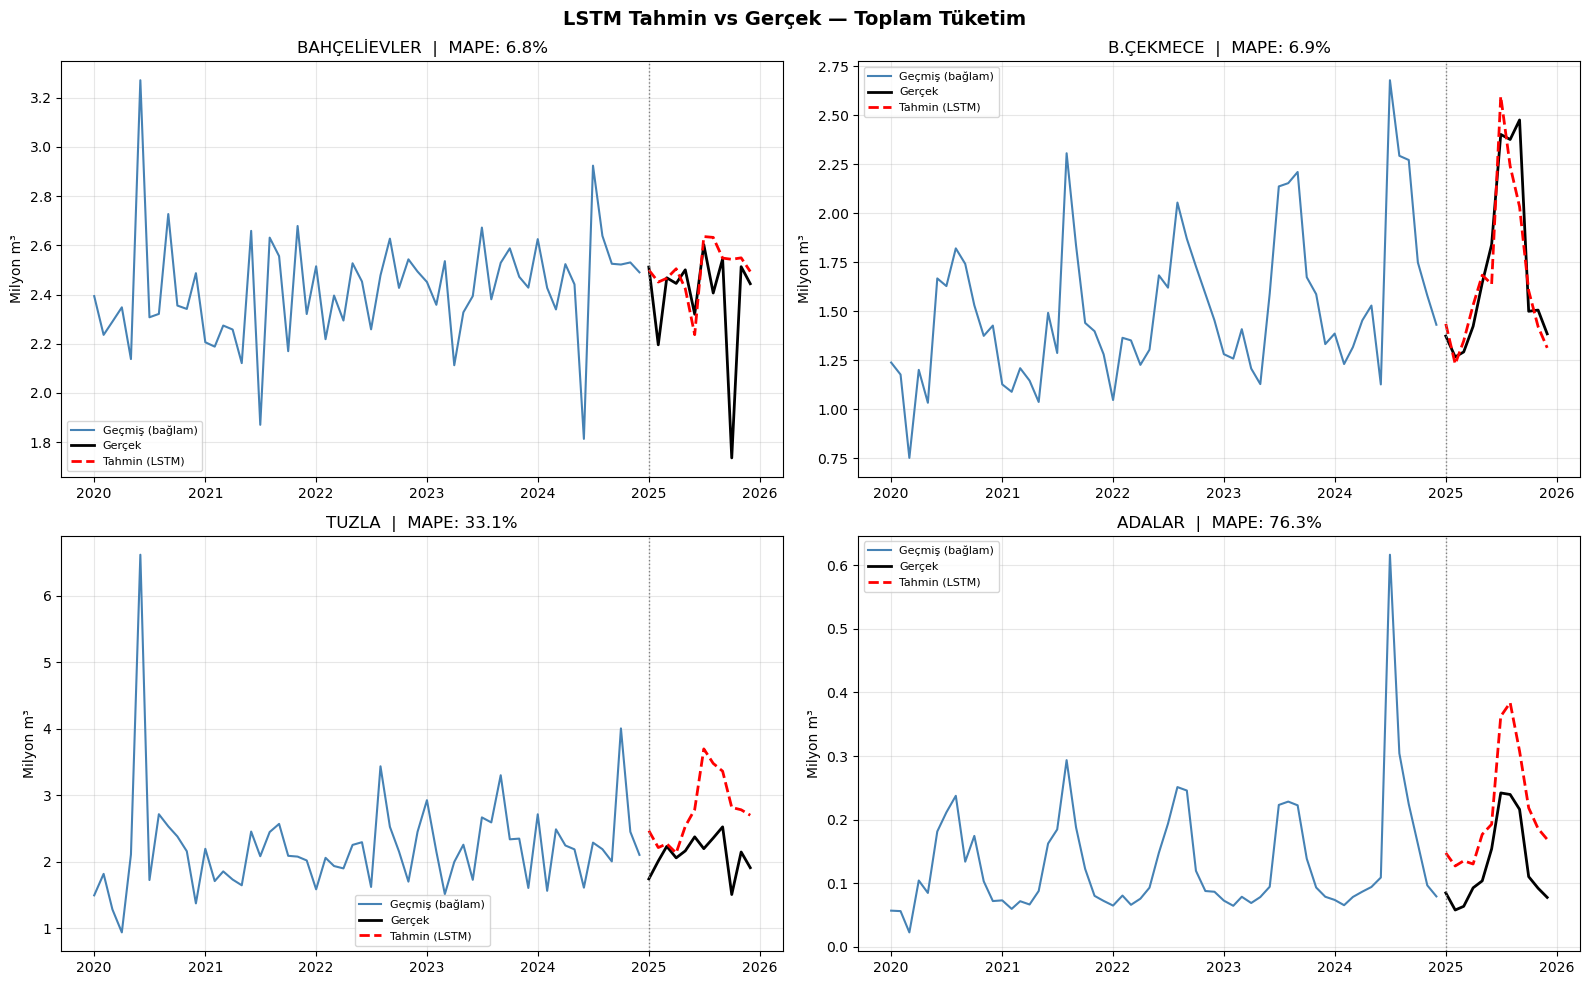

✅ Tahmin grafikleri kaydedildi: tahmin_grafikleri_lstm.png


In [21]:
# ── AŞAMA 20: TAHMİN GRAFİKLERİ ────────────────────────────
en_iyi  = metrikler.head(2)["unique_id"].tolist()
en_kotu = metrikler.tail(2)["unique_id"].tolist()
gosterilecek = en_iyi + en_kotu

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("LSTM Tahmin vs Gerçek — Toplam Tüketim", fontsize=14, fontweight="bold")

for ax, ilce in zip(axes.flatten(), gosterilecek):
    gecmis_k = df_full_konut[df_full_konut["unique_id"]   == ilce]
    gecmis_i = df_full_isyeri[df_full_isyeri["unique_id"] == ilce]
    gecmis_k = gecmis_k[gecmis_k["ds"] <= "2024-12-01"].copy()
    gecmis_i = gecmis_i[gecmis_i["ds"] <= "2024-12-01"].copy()
    gecmis_k["toplam"] = gecmis_k["y"].values + gecmis_i["y"].values

    k        = karsilastirma[karsilastirma["unique_id"] == ilce]
    mape_val = metrikler[metrikler["unique_id"] == ilce]["MAPE_Toplam"].values[0]

    ax.plot(gecmis_k["ds"], gecmis_k["toplam"] / 1e6,
            color="steelblue", linewidth=1.5, label="Geçmiş (bağlam)")
    ax.plot(k["ds"], k["toplam_gercek"] / 1e6,
            color="black", linewidth=2, label="Gerçek")
    ax.plot(k["ds"], k["toplam_tahmin"] / 1e6,
            color="red", linewidth=2, linestyle="--", label="Tahmin (LSTM)")
    ax.axvline(pd.Timestamp("2025-01-01"), color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"{ilce}  |  MAPE: {mape_val:.1f}%")
    ax.set_ylabel("Milyon m³")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tahmin_grafikleri_lstm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Tahmin grafikleri kaydedildi: tahmin_grafikleri_lstm.png")

In [22]:
# ── AŞAMA 21: SONUÇLARI EXCEL'E KAYDET ─────────────────────
CIKTI_DOSYASI = r"C:\Users\mynet\OneDrive\Masaüstü\istanbul_su_tahmini_lstm.xlsx"

with pd.ExcelWriter(CIKTI_DOSYASI, engine="openpyxl") as writer:
    karsilastirma.to_excel(writer, sheet_name="Tahmin vs Gerçek",  index=False)
    metrikler.to_excel(    writer, sheet_name="Performans",         index=False)
    tahminler.to_excel(    writer, sheet_name="Tahminler",          index=False)
    df_ctx_konut.to_excel( writer, sheet_name="Bağlam Konut",      index=False)
    df_ctx_isyeri.to_excel(writer, sheet_name="Bağlam İşyeri",     index=False)
    df.to_excel(           writer, sheet_name="Ham Veri",           index=False)

print(f"✅ Excel kaydedildi: {CIKTI_DOSYASI}")
print("\n🎉 Tüm işlem tamamlandı! (LSTM)")

✅ Excel kaydedildi: C:\Users\mynet\OneDrive\Masaüstü\istanbul_su_tahmini_lstm.xlsx

🎉 Tüm işlem tamamlandı! (LSTM)
